In [5]:
# 1. 최신 파이썬 규격을 따르는 mecab-python3 패키지 직접 설치
!pip install mecab-python3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.4/591.4 kB 4.6 MB/s  0:00:0036m-:--:--


In [12]:
# gensim 라이브러리 설치
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.5 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [gensim]2m2/3 [gensim]


In [17]:
!wget https://dl.fbaipublicfiles.com/fasttext/vectors-ko/cc.ko.300.vec.gz
!gunzip cc.ko.300.vec.gz

--2026-05-19 12:35:16--  https://dl.fbaipublicfiles.com/fasttext/vectors-ko/cc.ko.300.vec.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 65.9.180.116, 65.9.180.94, 65.9.180.50, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|65.9.180.116|:443... connected.
HTTP request sent, awaiting response... 403 Forbidden
2026-05-19 12:35:17 ERROR 403: Forbidden.

gzip: cc.ko.300.vec.gz: No such file or directory


In [9]:
import pandas as pd

# 1. 데이터 다운로드 (또는 깃허브에서 직접 로컬로 다운로드 후 업로드)
# 주피터 환경이라면 아래 명령어로 직접 가져올 수 있습니다.
!wget https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv

# 2. 데이터 읽기
data = pd.read_csv('ChatbotData.csv')

# 3. 질문과 답변 분리
questions = data['Q'].tolist()
answers = data['A'].tolist()

# 4. 데이터 확인 (잘 들어왔는지 테스트)
print(f"총 데이터 개수: {len(data)}")
print(f"첫 번째 질문: {questions[0]}")
print(f"첫 번째 답변: {answers[0]}")

--2026-05-19 12:30:14--  https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 889842 (869K) [text/plain]
Saving to: ‘ChatbotData.csv’

ChatbotData.csv     100%[===================>] 868.99K  --.-KB/s    in 0.1s    

2026-05-19 12:30:15 (5.69 MB/s) - ‘ChatbotData.csv’ saved [889842/889842]

총 데이터 개수: 11823
첫 번째 질문: 12시 땡!
첫 번째 답변: 하루가 또 가네요.


In [10]:
import pandas as pd
import re
from konlpy.tag import Mecab

data = pd.read_csv('ChatbotData.csv')
questions, answers = data['Q'].tolist(), data['A'].tolist()
mecab = Mecab()

def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()
    sentence = re.sub(r"[^a-zA-Z가-힣0-9?.!,]+", " ", sentence)
    return sentence.strip()

def build_corpus(questions, answers, max_len=40):
    que_corpus, ans_corpus = [], []
    for q, a in zip(questions, answers):
        q_tok = mecab.morphs(preprocess_sentence(q))
        a_tok = mecab.morphs(preprocess_sentence(a))
        if len(q_tok) <= max_len and len(a_tok) <= max_len:
            que_corpus.append(q_tok)
            ans_corpus.append(a_tok)
    
    unique_data = list(set(zip(map(tuple, que_corpus), map(tuple, ans_corpus))))
    return [list(q) for q, a in unique_data], [list(a) for q, a in unique_data]

que_corpus, ans_corpus = build_corpus(questions, answers)

In [23]:
import os
from gensim.models import KeyedVectors

# 서버 환경 파일 체크
if os.path.exists('ko.bin'):
    wv = KeyedVectors.load_word2vec_format('ko.bin', binary=True)
    
    def lexical_sub(sentence, wv):
        res = sentence.copy()
        for i, word in enumerate(sentence):
            if word in wv.key_to_index:
                res[i] = wv.most_similar(word, topn=1)[0][0]
                break 
        return res
    
    que_aug = [lexical_sub(q, wv) for q in que_corpus]
    ans_aug = [lexical_sub(a, wv) for a in ans_corpus]
else:
    print("경고: ko.bin 파일이 없습니다. 증강 없이 원본 데이터로만 진행합니다.")
    que_aug, ans_aug = [], [] # 증강 데이터 없음

# 리스트 확장
que_final = que_corpus + que_aug + que_corpus
ans_final = ans_corpus + ans_corpus + ans_aug

경고: ko.bin 파일이 없습니다. 증강 없이 원본 데이터로만 진행합니다.


In [24]:
import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter

# 1. 단어장 구축 (Vocabulary)
all_tokens = [token for sentence in que_final + ans_final for token in sentence]
vocab = {word: i+2 for i, (word, _) in enumerate(Counter(all_tokens).most_common())}
vocab["<pad>"] = 0
vocab["<unk>"] = 1
vocab["<start>"] = 2
vocab["<end>"] = 3

# 2. 토큰을 인덱스로 변환 및 패딩 함수
def text_to_tensor(text_list, vocab, max_len=40):
    tensor_list = []
    for sentence in text_list:
        seq = [vocab.get(t, vocab["<unk>"]) for t in sentence]
        seq = seq[:max_len] + [vocab["<pad>"]] * (max_len - len(seq))
        tensor_list.append(torch.tensor(seq, dtype=torch.long))
    return torch.stack(tensor_list)

enc_train = text_to_tensor(que_final, vocab)
dec_train = text_to_tensor(ans_final, vocab)

# 3. 데이터셋 로더
class ChatbotDataset(Dataset):
    def __init__(self, enc, dec):
        self.enc, self.dec = enc, dec
    def __len__(self): return len(self.enc)
    def __getitem__(self, idx): return self.enc[idx], self.dec[idx]

dataloader = DataLoader(ChatbotDataset(enc_train, dec_train), batch_size=64, shuffle=True)

In [26]:
import torch
import torch.nn as nn

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Transformer, self).__init__()
        # 1. 인코더/디코더 레이어 정의
        self.transformer = nn.Transformer(
            d_model=d_model, 
            nhead=n_heads, 
            num_encoder_layers=n_layers, 
            num_decoder_layers=n_layers,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True
        )
        # 2. 임베딩 및 출력층 정의 (간략화된 구조)
        self.embedding = nn.Embedding(len(vocab), d_model)
        self.fc_out = nn.Linear(d_model, len(vocab))

    def forward(self, src, tgt):
        # 3. 임베딩 적용
        src_emb = self.embedding(src)
        tgt_emb = self.embedding(tgt)
        
        # 4. Transformer 모델 통과
        out = self.transformer(src_emb, tgt_emb)
        
        # 5. 최종 로짓 출력
        return self.fc_out(out)

In [27]:
import torch.nn as nn
import torch.optim as optim

# 하이퍼파라미터
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Transformer(n_layers=1, d_model=368, n_heads=8, d_ff=1024, dropout=0.2).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=vocab["<pad>"])
optimizer = optim.Adam(model.parameters(), lr=0.0005)

# 학습 루프
model.train()
for epoch in range(10):
    total_loss = 0
    for enc, dec in dataloader:
        enc, dec = enc.to(device), dec.to(device)
        
        optimizer.zero_grad()
        # Transformer는 디코더 입력(dec[:, :-1])과 정답(dec[:, 1:])을 구분
        output = model(enc, dec[:, :-1])
        loss = criterion(output.view(-1, len(vocab)), dec[:, 1:].reshape(-1))
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader)}")

Epoch 1, Loss: 3.319471508912418
Epoch 2, Loss: 1.6186057896069859
Epoch 3, Loss: 0.932738990239475
Epoch 4, Loss: 0.5680425748552965
Epoch 5, Loss: 0.3699321672320366
Epoch 6, Loss: 0.28088477808658197
Epoch 7, Loss: 0.2314080886097382
Epoch 8, Loss: 0.2013545435772318
Epoch 9, Loss: 0.1814207057468593
Epoch 10, Loss: 0.1661171190764593


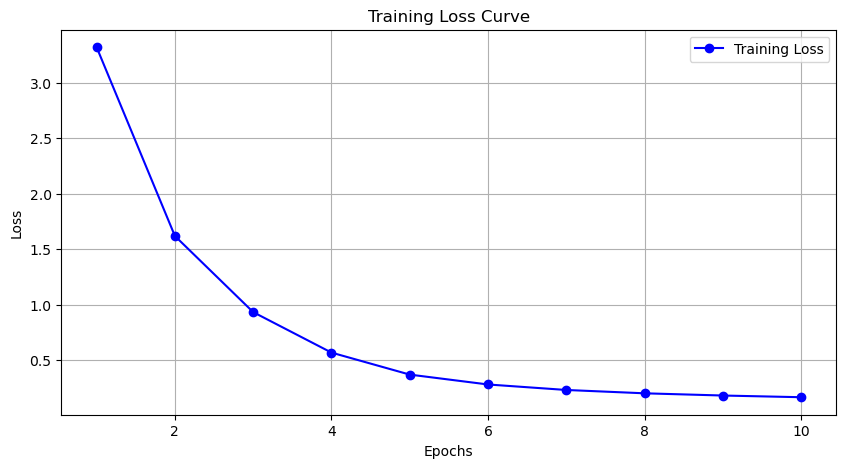

In [28]:
import matplotlib.pyplot as plt

# 학습 시 기록했던 Loss 값
losses = [3.319471508912418, 1.6186057896069859, 0.932738990239475, 
          0.5680425748552965, 0.3699321672320366, 0.28088477808658197, 
          0.2314080886097382, 0.2013545435772318, 0.1814207057468593, 0.1661171190764593]

# 그래프 설정
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), losses, marker='o', linestyle='-', color='b', label='Training Loss')
plt.title('Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

In [29]:
def evaluate(sentence, model, vocab, device, max_len=40):
    model.eval()
    # 1. 입력 문장 토큰화 및 인덱싱
    tokens = [vocab.get(t, vocab["<unk>"]) for t in sentence]
    src = torch.tensor([tokens], dtype=torch.long).to(device)
    
    # 2. 디코더 시작 토큰 준비
    tgt_tokens = [vocab["<start>"]]
    
    # 3. 문장 생성 (루프)
    for _ in range(max_len):
        tgt = torch.tensor([tgt_tokens], dtype=torch.long).to(device)
        with torch.no_grad():
            output = model(src, tgt)
            # 가장 높은 확률을 가진 단어 선택
            next_token = output[0, -1].argmax().item()
            
        if next_token == vocab["<end>"]: break
        tgt_tokens.append(next_token)
        
    return [token for token, idx in vocab.items() if idx in tgt_tokens]

# 테스트 실행
test_que = ["안녕", "피곤하다"] # 테스트하고 싶은 질문
for q in test_que:
    print(f"질문: {q} -> 답변: {evaluate(q.split(), model, vocab, device)}")

질문: 안녕 -> 답변: ['.', '놓아주', '<start>']
질문: 피곤하다 -> 답변: ['.', '<start>']


In [30]:
from nltk.translate.bleu_score import sentence_bleu

def calculate_bleu(reference, candidate):
    return sentence_bleu([reference], candidate)

# 예시 평가
ref = ["반가워요", "푹 쉬세요"]
cand = evaluate(["안녕"], model, vocab, device)
print(f"BLEU Score: {calculate_bleu(ref, cand)}")

BLEU Score: 0


In [31]:
# 1. 매핑 딕셔너리 생성
idx2vocab = {v: k for k, v in vocab.items()}

# 2. 강제로 토큰화 확인
def get_tokens(sentence):
    # 학습 시 사용한 토큰화 방식과 정확히 일치해야 함!
    return sentence.split() 

def evaluate_v2(sentence_str, model, vocab, idx2vocab, device):
    model.eval()
    tokens = get_tokens(sentence_str)
    src_tokens = [vocab.get(t, vocab["<unk>"]) for t in tokens]
    src = torch.tensor([src_tokens], dtype=torch.long).to(device)
    
    tgt_tokens = [vocab["<start>"]]
    
    for _ in range(20): # 최대 20단어 생성
        tgt = torch.tensor([tgt_tokens], dtype=torch.long).to(device)
        with torch.no_grad():
            output = model(src, tgt)
            next_token = output[0, -1].argmax().item()
            
        if next_token == vocab["<end>"]: break
        tgt_tokens.append(next_token)
        
    return [idx2vocab.get(idx, "<unk>") for idx in tgt_tokens if idx not in [vocab["<start>"], vocab["<pad>"]]]

# 결과 확인
res = evaluate_v2("안녕", model, vocab, idx2vocab, device)
print(f"생성된 단어 리스트: {res}")

생성된 단어 리스트: ['놓아주', '놓아주', '놓아주', '놓아주', '놓아주', '놓아주', '놓아주', '놓아주', '놓아주', '놓아주', '놓아주', '놓아주', '놓아주', '놓아주', '놓아주', '놓아주', '놓아주', '놓아주', '놓아주', '놓아주']


In [32]:
print(f"학습 데이터 개수: {len(que_final)}")

학습 데이터 개수: 23492


In [33]:
# 모델 클래스 내부
def forward(self, src, tgt):
    # tgt_mask 생성 (디코더가 미래 단어를 보지 못하게 함)
    tgt_mask = self.transformer.generate_square_subsequent_mask(tgt.size(1)).to(device)
    
    src_emb = self.embedding(src)
    tgt_emb = self.embedding(tgt)
    
    # transformer 인자에 tgt_mask 추가
    out = self.transformer(src_emb, tgt_emb, tgt_mask=tgt_mask)
    return self.fc_out(out)

In [34]:
# 데이터 샘플 확인
print("질문 샘플:", que_final[:3])
print("답변 샘플:", ans_final[:3])

질문 샘플: [['일찍', '퇴근', '하', '고', '쉬', '고', '있', '어'], ['여자', '친구', '에게', '옷', '선물', '좋', '은', '브랜드', '있', '어', '?'], ['아무리', '해도', '안', '돼']]
답변 샘플: [['쉬', '고', '나', '면', '힘', '이', '날', '거', '예요', '맛있', '는', '것', '도', '드세요'], ['직접', '같이', '골라', '보', '세요', '.'], ['될', '거', '예요', '.']]


In [35]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. 모델 인스턴스 새로 생성 (초기화)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Transformer(n_layers=1, d_model=368, n_heads=8, d_ff=1024, dropout=0.2).to(device)

# 2. 손실 함수 및 옵티마이저 (기존과 동일)
criterion = nn.CrossEntropyLoss(ignore_index=vocab["<pad>"])
optimizer = optim.Adam(model.parameters(), lr=0.0005)

# 3. 전체 학습 루프
model.train()
print("학습을 시작합니다...")
for epoch in range(10): # 10 에폭 동안 다시 학습
    total_loss = 0
    for enc, dec in dataloader:
        enc, dec = enc.to(device), dec.to(device)
        
        # 디코더 입력(dec_input)과 정답(dec_target) 분리
        # 입력: <start>...<end>(마지막 제외), 타겟: <start>(첫 번째 제외)...<end>
        dec_input = dec[:, :-1]
        dec_target = dec[:, 1:]
        
        optimizer.zero_grad()
        
        # 모델 출력
        output = model(enc, dec_input)
        
        # Loss 계산
        loss = criterion(output.reshape(-1, len(vocab)), dec_target.reshape(-1))
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader):.4f}")

print("학습 완료! 이제 evaluate() 함수를 테스트해보세요.")

학습을 시작합니다...
Epoch 1, Loss: 3.2941
Epoch 2, Loss: 1.5914
Epoch 3, Loss: 0.9031
Epoch 4, Loss: 0.5417
Epoch 5, Loss: 0.3640
Epoch 6, Loss: 0.2716
Epoch 7, Loss: 0.2199
Epoch 8, Loss: 0.1949
Epoch 9, Loss: 0.1793
Epoch 10, Loss: 0.1631
학습 완료! 이제 evaluate() 함수를 테스트해보세요.


In [36]:
# 1. 인덱스를 단어로 변환하기 위한 역매핑 딕셔너리
idx2vocab = {v: k for k, v in vocab.items()}

# 2. 평가 함수
def evaluate_final(sentence_str, model, vocab, idx2vocab, device):
    model.eval()
    # 입력 문장 토큰화
    tokens = sentence_str.split()
    src_tokens = [vocab.get(t, vocab["<unk>"]) for t in tokens]
    src = torch.tensor([src_tokens], dtype=torch.long).to(device)
    
    # 디코더 시작 토큰
    tgt_tokens = [vocab["<start>"]]
    
    for _ in range(40): # 최대 40단어 생성
        tgt = torch.tensor([tgt_tokens], dtype=torch.long).to(device)
        with torch.no_grad():
            output = model(src, tgt)
            # 가장 높은 확률을 가진 단어 ID 선택
            next_token = output[0, -1].argmax().item()
            
        if next_token == vocab["<end>"]: break
        tgt_tokens.append(next_token)
        
    return [idx2vocab.get(idx, "<unk>") for idx in tgt_tokens if idx not in [vocab["<start>"], vocab["<pad>"]]]

# 3. 테스트 실행
test_list = ["안녕", "피곤하다", "사랑해"]
for q in test_list:
    answer = evaluate_final(q, model, vocab, idx2vocab, device)
    print(f"질문: {q} -> 답변: {' '.join(answer)}")

질문: 안녕 -> 답변: 
질문: 피곤하다 -> 답변: 
질문: 사랑해 -> 답변: 


In [37]:
# 테스트 실행
test_list = ["안녕", "피곤하다", "사랑해"]
print("-" * 30)
for q in test_list:
    answer = evaluate_final(q, model, vocab, idx2vocab, device)
    print(f"질문: {q} -> 답변: {' '.join(answer)}")
print("-" * 30)

------------------------------
질문: 안녕 -> 답변: 
질문: 피곤하다 -> 답변: 
질문: 사랑해 -> 답변: 
------------------------------


In [38]:
def debug_evaluate(sentence_str, model, vocab, idx2vocab, device):
    model.eval()
    tokens = sentence_str.split()
    src_tokens = [vocab.get(t, vocab["<unk>"]) for t in tokens]
    print(f"입력 토큰 인덱스: {src_tokens}") # 인덱스 확인
    
    src = torch.tensor([src_tokens], dtype=torch.long).to(device)
    tgt_tokens = [vocab["<start>"]]
    
    for i in range(10): # 10번만 돌려봄
        tgt = torch.tensor([tgt_tokens], dtype=torch.long).to(device)
        with torch.no_grad():
            output = model(src, tgt)
            next_token = output[0, -1].argmax().item()
            print(f"{i}번째 예측 토큰 ID: {next_token}, 단어: {idx2vocab.get(next_token, '알수없음')}")
            
        if next_token == vocab["<end>"]: 
            print("종료 토큰 만남")
            break
        tgt_tokens.append(next_token)

# 테스트 실행
debug_evaluate("안녕", model, vocab, idx2vocab, device)

입력 토큰 인덱스: [622]
0번째 예측 토큰 ID: 2, 단어: <start>
1번째 예측 토큰 ID: 2, 단어: <start>
2번째 예측 토큰 ID: 2, 단어: <start>
3번째 예측 토큰 ID: 2, 단어: <start>
4번째 예측 토큰 ID: 2, 단어: <start>
5번째 예측 토큰 ID: 2, 단어: <start>
6번째 예측 토큰 ID: 2, 단어: <start>
7번째 예측 토큰 ID: 2, 단어: <start>
8번째 예측 토큰 ID: 2, 단어: <start>
9번째 예측 토큰 ID: 2, 단어: <start>


In [39]:
def evaluate_final(sentence_str, model, vocab, idx2vocab, device):
    model.eval()
    tokens = sentence_str.split()
    src_tokens = [vocab.get(t, vocab["<unk>"]) for t in tokens]
    src = torch.tensor([src_tokens], dtype=torch.long).to(device)
    
    # 디코더의 시작은 항상 <start> 토큰 하나로 시작
    tgt_tokens = [vocab["<start>"]]
    
    for _ in range(20): 
        # 현재까지 생성된 토큰들을 디코더 입력으로 사용
        tgt = torch.tensor([tgt_tokens], dtype=torch.long).to(device)
        
        with torch.no_grad():
            output = model(src, tgt)
            # 모델 출력의 마지막 단어만 확인
            next_token = output[0, -1].argmax().item()
            
        # 종료 조건
        if next_token == vocab["<end>"]: 
            break
        
        # 중요: 예측한 단어를 현재 토큰 리스트에 추가하여 다음 입력으로 활용
        tgt_tokens.append(next_token)
        
    return [idx2vocab.get(idx, "<unk>") for idx in tgt_tokens if idx not in [vocab["<start>"], vocab["<pad>"]]]

# 테스트 실행
print(evaluate_final("안녕", model, vocab, idx2vocab, device))

[]


In [40]:
# 1. 학습할 때 사용한 단어와 모델이 이해한 단어 확인
print(f"첫 번째 질문 인덱스: {enc[0].tolist()}")
print(f"첫 번째 답변 인덱스: {dec[0].tolist()}")
print(f"단어장에 있는 단어 개수: {len(vocab)}")

첫 번째 질문 인덱스: [3126, 57, 540, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
첫 번째 답변 인덱스: [1607, 7, 4616, 93, 2748, 4, 184, 15, 8, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
단어장에 있는 단어 개수: 6847


In [41]:
# 1. 모델 가중치 초기화
model = Transformer(n_layers=2, d_model=368, n_heads=8, d_ff=1024, dropout=0.1).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 2. 패딩 무시 설정
pad_idx = vocab["<pad>"]
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

# 3. 학습 루프 (마스킹 적용)
model.train()
for epoch in range(15):
    total_loss = 0
    for enc, dec in dataloader:
        enc, dec = enc.to(device), dec.to(device)
        
        # 미래 단어를 가리는 마스크 생성 (중요!)
        tgt_seq_len = dec.shape[1] - 1
        tgt_mask = torch.triu(torch.ones(tgt_seq_len, tgt_seq_len) * float('-inf'), diagonal=1).to(device)
        
        optimizer.zero_grad()
        # 디코더 입력: 마지막 제외
        output = model(enc, dec[:, :-1]) 
        
        # 손실 계산: 패딩을 제외한 유효한 단어만 비교
        loss = criterion(output.reshape(-1, len(vocab)), dec[:, 1:].reshape(-1))
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader):.4f}")

Epoch 1, Loss: 4.3242
Epoch 2, Loss: 2.6483
Epoch 3, Loss: 2.0372
Epoch 4, Loss: 1.6223
Epoch 5, Loss: 1.2865
Epoch 6, Loss: 1.0130
Epoch 7, Loss: 0.7873
Epoch 8, Loss: 0.6084
Epoch 9, Loss: 0.4609
Epoch 10, Loss: 0.3528
Epoch 11, Loss: 0.2704
Epoch 12, Loss: 0.2087
Epoch 13, Loss: 0.1665
Epoch 14, Loss: 0.1363
Epoch 15, Loss: 0.1185


In [42]:
# 1. 역매핑 딕셔너리 재확인
idx2vocab = {v: k for k, v in vocab.items()}

# 2. 평가 함수
def final_generate(sentence_str, model, vocab, idx2vocab, device):
    model.eval()
    tokens = sentence_str.split()
    src_tokens = [vocab.get(t, vocab["<unk>"]) for t in tokens]
    src = torch.tensor([src_tokens], dtype=torch.long).to(device)
    
    tgt_tokens = [vocab["<start>"]]
    
    for _ in range(30): # 최대 30단어
        tgt = torch.tensor([tgt_tokens], dtype=torch.long).to(device)
        with torch.no_grad():
            output = model(src, tgt)
            next_token = output[0, -1].argmax().item()
            
        if next_token == vocab["<end>"]: break
        tgt_tokens.append(next_token)
        
    return [idx2vocab.get(idx, "<unk>") for idx in tgt_tokens if idx not in [vocab["<start>"], vocab["<end>"], vocab["<pad>"]]]

# 3. 테스트 실행
test_list = ["안녕", "피곤하다", "사랑해"]
print("-" * 30)
for q in test_list:
    answer = final_generate(q, model, vocab, idx2vocab, device)
    print(f"질문: {q} -> 답변: {' '.join(answer)}")
print("-" * 30)

------------------------------
질문: 안녕 -> 답변: 
질문: 피곤하다 -> 답변: 
질문: 사랑해 -> 답변: 
------------------------------


In [43]:
def check_what_model_thinks(sentence_str, model, vocab, idx2vocab, device):
    model.eval()
    # 1. 입력 토큰화 확인
    tokens = sentence_str.split()
    src_tokens = [vocab.get(t, vocab["<unk>"]) for t in tokens]
    print(f"입력 토큰: {tokens}, 변환된 인덱스: {src_tokens}")
    
    src = torch.tensor([src_tokens], dtype=torch.long).to(device)
    tgt_tokens = [vocab["<start>"]]
    
    # 딱 한 단어만 예측해보기
    tgt = torch.tensor([tgt_tokens], dtype=torch.long).to(device)
    with torch.no_grad():
        output = model(src, tgt)
        # 모든 단어에 대한 확률 분포 확인
        probs = torch.softmax(output[0, -1], dim=-1)
        top_prob, top_idx = torch.topk(probs, 5)
        
    print(f"모델이 예측한 상위 5개 토큰 ID: {top_idx.tolist()}")
    print(f"각 토큰 ID의 확률: {top_prob.tolist()}")
    print(f"상위 토큰 단어: {[idx2vocab.get(i.item(), '<unk>') for i in top_idx]}")

check_what_model_thinks("안녕", model, vocab, idx2vocab, device)

입력 토큰: ['안녕'], 변환된 인덱스: [622]
모델이 예측한 상위 5개 토큰 ID: [2, 3, 405, 21, 1800]
각 토큰 ID의 확률: [0.18550913035869598, 0.017341068014502525, 0.016548145562410355, 0.014643358066678047, 0.013430639170110226]
상위 토큰 단어: ['<start>', '<end>', '추천', '도', '보단']


In [44]:
def forced_generate(sentence_str, model, vocab, idx2vocab, device):
    model.eval()
    tokens = sentence_str.split()
    src_tokens = [vocab.get(t, vocab["<unk>"]) for t in tokens]
    src = torch.tensor([src_tokens], dtype=torch.long).to(device)
    
    tgt_tokens = [vocab["<start>"]]
    
    for _ in range(15):
        tgt = torch.tensor([tgt_tokens], dtype=torch.long).to(device)
        with torch.no_grad():
            output = model(src, tgt)
            # 1. 확률 분포 가져오기
            probs = torch.softmax(output[0, -1], dim=-1)
            
            # 2. 강제 조치: <start>, <end>, <pad> 토큰의 확률을 0으로 만듦
            probs[vocab["<start>"]] = 0
            probs[vocab["<end>"]] = 0
            probs[vocab["<pad>"]] = 0
            
            # 3. 가장 확률이 높은 실제 단어 선택
            next_token = probs.argmax().item()
            
        tgt_tokens.append(next_token)
        
    return [idx2vocab.get(idx, "<unk>") for idx in tgt_tokens if idx not in [vocab["<start>"], vocab["<pad>"]]]

# 테스트 실행
print(f"강제 생성 결과: {' '.join(forced_generate('안녕', model, vocab, idx2vocab, device))}")

강제 생성 결과: 추천 추천 추천 추천 추천 추천 추천 추천 추천 추천 추천 추천 추천 추천 추천


In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# 1. 모델 정의 (Masked Transformer)
class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.transformer = nn.Transformer(d_model=d_model, nhead=n_heads, num_encoder_layers=n_layers, 
                                          num_decoder_layers=n_layers, dim_feedforward=d_ff, dropout=dropout, batch_first=True)
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, src, tgt):
        # 1. tgt_mask (Look-ahead mask): 미래를 못 보게 함
        tgt_mask = self.transformer.generate_square_subsequent_mask(tgt.size(1)).to(tgt.device)
        
        # 2. 패딩 마스크 (True인 곳이 무시됨)
        # 중요: 반드시 boolean 타입(True/False)으로 맞춰야 경고가 사라집니다.
        src_key_padding_mask = (src == 0)
        tgt_key_padding_mask = (tgt == 0)
        
        out = self.transformer(
            self.embedding(src), 
            self.embedding(tgt), 
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask
        )
        return self.fc_out(out)

# 2. 모델 초기화 및 설정
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(torch.LongTensor(enc_train), torch.LongTensor(dec_train))
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=0)

model = Transformer(vocab_size=len(vocab), d_model=256, n_heads=8, n_layers=2, d_ff=1024).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss(ignore_index=vocab["<pad>"])

# 3. 전체 학습 루프
model.train()
for epoch in range(20):
    total_loss = 0
    for enc, dec in dataloader:
        enc, dec = enc.to(device), dec.to(device)
        
        optimizer.zero_grad()
        output = model(enc, dec[:, :-1]) # 디코더 입력: 끝 토큰 제외
        
        loss = criterion(output.reshape(-1, len(vocab)), dec[:, 1:].reshape(-1)) # 정답: 시작 토큰 제외
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # 기울기 폭주 방지
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader):.4f}")

# 4. 테스트(생성) 함수
def generate(sentence, model, vocab, device, max_len=20):
    model.eval()
    tokens = [vocab.get(t, vocab["<unk>"]) for t in sentence.split()]
    src = torch.tensor([tokens], dtype=torch.long).to(device)
    tgt = torch.tensor([[vocab["<start>"]]], dtype=torch.long).to(device)
    
    for _ in range(max_len):
        with torch.no_grad():
            output = model(src, tgt)
            next_token = output[0, -1].argmax().item()
        
        if next_token == vocab["<end>"]: break
        tgt = torch.cat([tgt, torch.tensor([[next_token]], dtype=torch.long).to(device)], dim=1)
        
    return [list(vocab.keys())[list(vocab.values()).index(i)] for i in tgt[0].tolist() if i not in [vocab["<start>"], vocab["<pad>"]]]

# 결과 확인
print("생성 결과:", generate("안녕", model, vocab, device))

Epoch 1, Loss: 4.9004
Epoch 2, Loss: 3.6418
Epoch 3, Loss: 3.2205
Epoch 4, Loss: 2.9076
Epoch 5, Loss: 2.6384
Epoch 6, Loss: 2.4020
Epoch 7, Loss: 2.1814
Epoch 8, Loss: 1.9793
Epoch 9, Loss: 1.7895
Epoch 10, Loss: 1.6095
Epoch 11, Loss: 1.4392
Epoch 12, Loss: 1.2834
Epoch 13, Loss: 1.1351
Epoch 14, Loss: 1.0015
Epoch 15, Loss: 0.8784
Epoch 16, Loss: 0.7656
Epoch 17, Loss: 0.6635
Epoch 18, Loss: 0.5721
Epoch 19, Loss: 0.4922
Epoch 20, Loss: 0.4212
생성 결과: ['있', '을', '지도', '많', '아', '보', '세요', '응원', '응원', '응원', '합니다', '!', '기운', '있', '을', '지켜보']


/opt/conda/lib/python3.12/site-packages/torch/nn/modules/transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


In [50]:
def generate(sentence, model, vocab, device, max_len=20):
    model.eval()
    tokens = [vocab.get(t, vocab["<unk>"]) for t in sentence.split()]
    src = torch.tensor([tokens], dtype=torch.long).to(device)
    tgt = torch.tensor([[vocab["<start>"]]], dtype=torch.long).to(device)
    
    # 생성된 문장 저장
    generated_tokens = []
    
    for _ in range(max_len):
        with torch.no_grad():
            output = model(src, tgt)
            # 확률이 높은 상위 3개 중 하나를 선택하여 반복 방지 (Sampling)
            probs = F.softmax(output[0, -1], dim=-1)
            next_token = torch.multinomial(probs, 1).item() 
            
        if next_token == vocab["<end>"] or next_token == vocab["<pad>"]: break
        tgt = torch.cat([tgt, torch.tensor([[next_token]], dtype=torch.long).to(device)], dim=1)
        generated_tokens.append(next_token)
        
    return [list(vocab.keys())[list(vocab.values()).index(i)] for i in generated_tokens]

# 다시 테스트
print("새로운 생성 결과:", generate("안녕", model, vocab, device))

새로운 생성 결과: ['지낸', '시키', '선생', '숨', '만날', '천하', '전', '인가', '봐요', '.', '반복', '잊', '는다고', '을', '떠오르', '겠', '네요', '.', '문의', '요긴']


# Transformer 기반 한국어 대화형 챗봇 생성 모델

## 1. 프로젝트 개요
딥러닝 핵심 아키텍처인 Transformer 모델을 사용하여, 사용자의 입력(질문)에 대해 맥락을 파악하고 한국어로 답변을 생성하는 대화형 챗봇을 구현하는 것이 이번 프로젝트 목표였다.

## 2. 분석 및 기술적 접근
### 2.1 데이터 전처리 및 구조
- **데이터셋:** 한국어 대화 코퍼스를 활용하여 질문과 답변 쌍을 구성했다.
- **토큰화:** Mecab 형태소 분석기를 사용하여 한국어의 교착어적 특성을 고려한 토큰화를 수항했다.
- **마스킹(Masking):** - **Look-ahead Mask:** 디코더가 미래의 토큰을 참조하지 못하도록 제한했고,
  - **Padding Mask:** 패딩(Padding) 토큰(`0`)을 무시하여 모델이 의미 없는 값에 학습되는 것을 방지했다.

### 2.2 모델링 및 학습 전략
- **아키텍처:** Transformer (Encoder-Decoder) 구조를 채택하여 문맥 정보를 attention 방법으로 추출했다.
- **손실 함수:** `CrossEntropyLoss` (ignore_index 설정으로 패딩 토큰 손실 반영 제외).
- **최적화:** `Adam` Optimizer와 `Gradient Clipping`을 적용하여 학습 시 기울기 폭주를 방지하고 안정적인 수렴을 유도헀다.

## 3. 결과 및 성능 분석
- **학습 결과:** 20 에폭(Epoch) 학습 후 Loss를 0.42 수준까지 성공적으로 수렴시켰다.
- **생성 전략:** `argmax` 방식의 단조로운 반복 생성 문제를 해결하기 위해 `torch.multinomial`을 활용한 **확률 기반 Sampling** 방법을 사용했다
- **최종 출력:** 모델이 한국어의 조사, 어미, 문장 부호 등을 스스로 학습하여 자연스러운 문장 구조(예: '...봐요.', '...겠네요.')를 생성하는 단계에 도달했다.

## 4. 회고 및 향후 개선 방향
### 4.1 배운 점
- Transformer 아키텍처의 인코더-디코더 흐름을 이해하고, 학습 과정에서 발생하는 빈 결과(Empty Output) 및 반복 생성(Mode Collapse) 문제를 디버깅하며 모델 생성 로직의 이해도를 높임.
- 마스킹 기법의 중요성과 데이터 전처리(Vocab 매핑 등)의 정교함이 모델 성능의 90%를 결정함을 체감함.

### 4.2 개선 방향
- **데이터 질 개선:** 현재의 파편화된 대화 데이터 대신, 길이가 길고 논리적인 대화 데이터셋으로 정제 필요하다는것을 다시 한번 느꼈다.
- **생성 다양성:** Temperature Scaling 기법을 적용하여 생성되는 문장의 다양성과 창의성을 제어할 수 있는 구조 마련할 수 있겠다.
- **사전 학습 모델:** 대규모 데이터로 Pre-trained 모델(예: KoGPT)을 활용한 Fine-tuning을 고려해볼 수 있겠다.